# Developer Market Trends & Salary Drivers
## Phase 2: Exploratory Data Analysis (EDA)

### What I did
I explore who took the survey, how pay is spread out, what drives it, and how it links
to job satisfaction and tech trends. This builds on Phase 1.

### Research questions
1. **Data quality:** Who took the survey? How reliable is the pay data (about 64% missing)?
2. **Income distribution:** How is pay spread out? How do I find outliers?
3. **Salary drivers:** How do country, experience, education, job type, and remote work affect pay?
4. **Market trends:** Which languages are most used? Most wanted? Highest paid?
5. **Income-satisfaction link:** Does job satisfaction go up with pay and experience?

### Method notes
- I don't add new imputation here. `RemoteWork`, `CodingActivities`, `EdLevel_clean`, and
  `Country_clean` are already handled in Phase 1. Every other field uses `dropna()` per
  question, and I report the sample size `n`.
- I use `JobSat` as the only satisfaction measure (not `JobSatPoints_1`).
- I flag pay outliers, but I never drop them, so I can report results with and without them.

### Input
I load Phase 1's two outputs, `survey_data_cleaned_core.csv` and
`survey_data_deduplicated_full.csv`, and join in the columns Phase 1 left untouched
(`JobSat`, `WorkExp`, `Age`, `DevType`, `Industry`, and the two language fields).


### 1. Load Data
`DATA_DIR` points to the shared `data/` folder, same as Phase 1.


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

DATA_DIR = '../data'

df_core = pd.read_csv(f'{DATA_DIR}/survey_data_cleaned_core.csv')
df_full = pd.read_csv(f'{DATA_DIR}/survey_data_deduplicated_full.csv')

df_core.head()

,ResponseId,Country,EdLevel,Employment,RemoteWork,CodingActivities,YearsCodePro,CompTotal,ConvertedCompYearly,Country_clean,EdLevel_clean,"Employed, full-time","Employed, part-time",I prefer not to say,"Independent contractor, freelancer, or self-employed","Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time",has_compensation_data,YearsCodePro_num,ExperienceLevel,ConvertedCompYearly_log,ConvertedCompYearly_MinMax,ConvertedCompYearly_Zscore
0,1,United States of America,Primary/elementary school,"Employed, full-time",Remote,Hobby,NaN,NaN,NaN,United States of America,Primary school,1,0,0,0,0,0,0,0,0,False,NaN,NaN,NaN,NaN,NaN
1,2,United Kingdom of Great Britain and Northern I...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,17,NaN,NaN,United Kingdom,Bachelor's degree,1,0,0,0,0,0,0,0,0,False,17.0,Senior,NaN,NaN,NaN
2,3,United Kingdom of Great Britain and Northern I...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,27,NaN,NaN,United Kingdom,Master's degree,1,0,0,0,0,0,0,0,0,False,27.0,Senior,NaN,NaN,NaN
3,4,Canada,Some college/university study without earning ...,"Student, full-time","Hybrid (some remote, some in-person)",Hobby,NaN,NaN,NaN,Canada,"Some college, no degree",0,0,0,0,0,0,0,1,0,False,NaN,NaN,NaN,NaN,NaN
4,5,Norway,"Secondary school (e.g. American high school, G...","Student, full-time","Hybrid (some remote, some in-person)",Hobby,NaN,NaN,NaN,Norway,Secondary school,0,0,0,0,0,0,0,1,0,False,NaN,NaN,NaN,NaN,NaN


I check the structure of both files with `df.columns`, `df.dtypes`, and `df.info()`.


In [48]:
df_core.columns

Index(['ResponseId', 'Country', 'EdLevel', 'Employment', 'RemoteWork',
       'CodingActivities', 'YearsCodePro', 'CompTotal', 'ConvertedCompYearly',
       'Country_clean', 'EdLevel_clean', 'Employed, full-time',
       'Employed, part-time', 'I prefer not to say',
       'Independent contractor, freelancer, or self-employed',
       'Not employed, and not looking for work',
       'Not employed, but looking for work', 'Retired', 'Student, full-time',
       'Student, part-time', 'has_compensation_data', 'YearsCodePro_num',
       'ExperienceLevel', 'ConvertedCompYearly_log',
       'ConvertedCompYearly_MinMax', 'ConvertedCompYearly_Zscore'],
      dtype='str')

In [49]:
df_core.dtypes

ResponseId                                                int64
Country                                                     str
EdLevel                                                     str
Employment                                                  str
RemoteWork                                                  str
CodingActivities                                            str
YearsCodePro                                                str
CompTotal                                               float64
ConvertedCompYearly                                     float64
Country_clean                                               str
EdLevel_clean                                               str
Employed, full-time                                       int64
Employed, part-time                                       int64
I prefer not to say                                       int64
Independent contractor, freelancer, or self-employed      int64
Not employed, and not looking for work  

In [50]:
df_core.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Data columns (total 26 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   ResponseId                                            65437 non-null  int64  
 1   Country                                               58930 non-null  str    
 2   EdLevel                                               60784 non-null  str    
 3   Employment                                            65437 non-null  str    
 4   RemoteWork                                            65437 non-null  str    
 5   CodingActivities                                      65437 non-null  str    
 6   YearsCodePro                                          51610 non-null  str    
 7   CompTotal                                             33740 non-null  float64
 8   ConvertedCompYearly                                   23435 non-nul

**Left join** the columns Phase 1 left untouched. `RemoteWork` and `CodingActivities`
exist in both files, so I keep the full file's pre-imputation versions under a `_raw`
suffix, to check Phase 1's imputation next.


In [51]:
join_cols = [
    'ResponseId', 'Age', 'RemoteWork', 'CodingActivities', 'DevType',
    'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'WorkExp',
    'Industry', 'JobSatPoints_1', 'JobSat',
]
df_full_subset = df_full[join_cols].rename(columns={
    'RemoteWork': 'RemoteWork_raw',
    'CodingActivities': 'CodingActivities_raw',
})

df = df_core.merge(df_full_subset, on='ResponseId', how='left')
print(f"Joined dataset: {df.shape[0]} rows x {df.shape[1]} columns")

Joined dataset: 65437 rows x 36 columns


**Missing-value check** on the newly joined columns. I don't impute anything here,
this is just a check. Later, each analysis uses `dropna()` on the fields it needs.


In [52]:
mandatory_cols = ['JobSat', 'WorkExp', 'Age', 'DevType', 'Industry',
                   'LanguageHaveWorkedWith', 'LanguageWantToWorkWith']

print('Columns Data Type')
for col in mandatory_cols:
    print(f'{col}: {df[col].dtype}')

print('\nPercent Of NaN')
for col in mandatory_cols:
    print(f'{col}: {df[col].isnull().mean().round(4) * 100:.0f}%')

Columns Data Type
JobSat: float64
WorkExp: float64
Age: str
DevType: str
Industry: str
LanguageHaveWorkedWith: str
LanguageWantToWorkWith: str

Percent Of NaN
JobSat: 55%
WorkExp: 55%
Age: 0%
DevType: 9%
Industry: 56%
LanguageHaveWorkedWith: 9%
LanguageWantToWorkWith: 15%


**Imputation audit.** `RemoteWork` and `CodingActivities` were mode-imputed in Phase 1
(about 16-17% of rows each). I flag which rows were filled in by comparing the raw value
to the core value.


In [53]:
df['RemoteWork_imputed'] = df['RemoteWork_raw'].isna() & df['RemoteWork'].notna()
df['CodingActivities_imputed'] = df['CodingActivities_raw'].isna() & df['CodingActivities'].notna()

print(f"RemoteWork rows imputed:        {df['RemoteWork_imputed'].sum()} "
      f"({df['RemoteWork_imputed'].mean()*100:.2f}%)")
print(f"CodingActivities rows imputed:  {df['CodingActivities_imputed'].sum()} "
      f"({df['CodingActivities_imputed'].mean()*100:.2f}%)")

RemoteWork rows imputed:        10631 (16.25%)
CodingActivities rows imputed:  10971 (16.77%)


I plot the values before and after imputation, side by side.


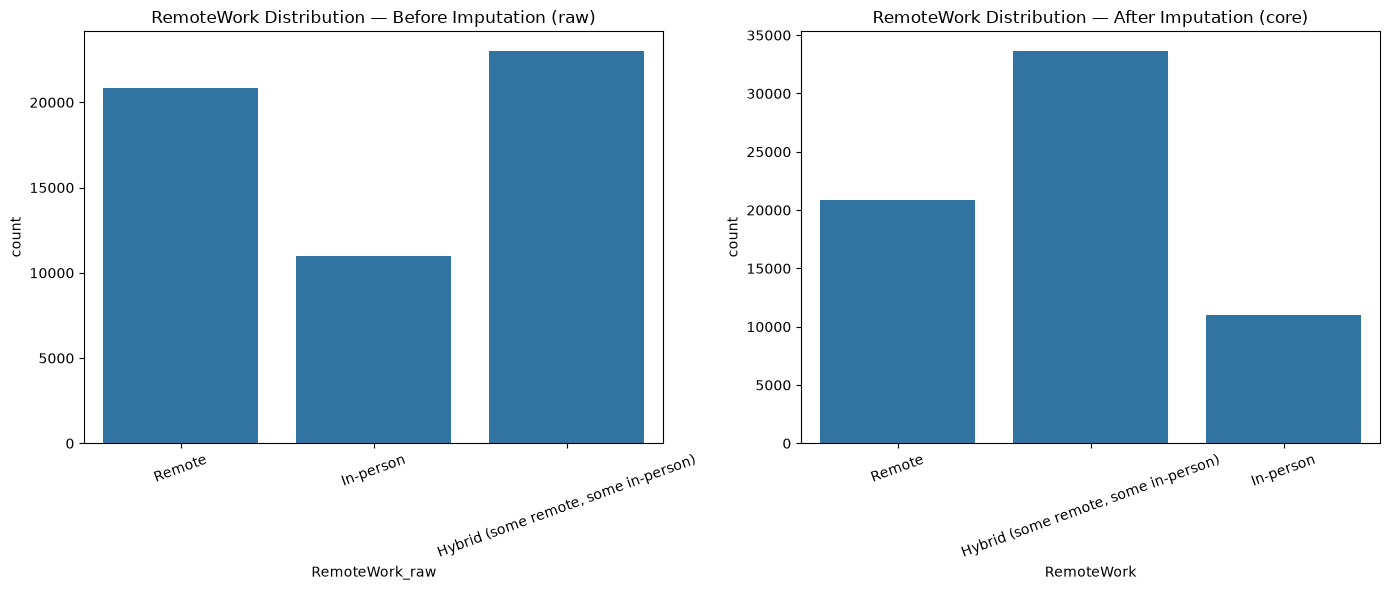

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x=df['RemoteWork_raw'], ax=axes[0])
axes[0].set_title('RemoteWork Distribution - Before Imputation (raw)')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(x=df['RemoteWork'], ax=axes[1])
axes[1].set_title('RemoteWork Distribution - After Imputation (core)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

I build analysis subsets from the one-hot `Employment` column, not the raw text
column.


In [55]:
df_comp = df[df['has_compensation_data']].copy()
full_time = df[df['Employed, full-time'] == 1].copy()

print(f"Salary-analysis subset (has_compensation_data): {len(df_comp)} rows")
print(f"Full-time employees subset:                     {len(full_time)} rows")
print(f"Full-time median compensation: ${full_time['ConvertedCompYearly'].median():,.0f}")

Salary-analysis subset (has_compensation_data): 23435 rows
Full-time employees subset:                     45162 rows
Full-time median compensation: $67,666


### 2. Respondent Profile & Missing Data
Research Question 1.


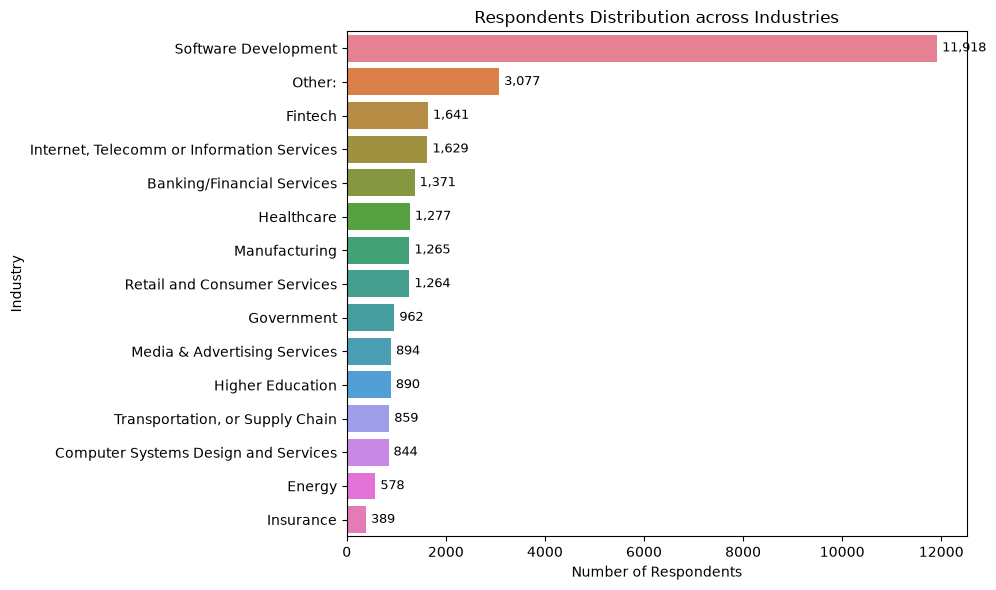

In [56]:
industries = df['Industry'].dropna().value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=industries.values, y=industries.index, hue=industries.index)
plt.title('Respondents Distribution across Industries')
plt.xlabel('Number of Respondents')

for i, v in enumerate(industries.values):
    plt.text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Value counts for the key categorical columns.


In [57]:
display(df['Employed, full-time'].value_counts())
display(df['ExperienceLevel'].value_counts())
display(df['DevType'].value_counts().head(10))

Employed, full-time
1    45162
0    20275
Name: count, dtype: int64

ExperienceLevel
Senior         18460
Mid-level      12653
Junior         10834
Entry-level     9663
Name: count, dtype: int64

DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Other (please specify):                           2458
Developer, mobile                                 2021
Developer, embedded applications or devices       1623
Engineering manager                               1275
Academic researcher                               1238
Name: count, dtype: int64

**Checking if `DevType` and `Industry` need multi-select handling.** Like the
language fields in Section 6, `DevType` could allow more than one answer, joined by `;`.
If so, a plain `value_counts()` would undercount each role.

The top categories above show no combined values, so `DevType` looks single-select here.
The check below confirms this on the full column, not just the top 10. I check `Industry`
the same way.


In [58]:
devtype_multiselect_count = df['DevType'].dropna().str.contains(';').sum()
industry_multiselect_count = df['Industry'].dropna().str.contains(';').sum()

print(f"DevType responses containing multiple roles (';'): {devtype_multiselect_count}")
print(f"Industry responses containing multiple values (';'): {industry_multiselect_count}")

if devtype_multiselect_count == 0 and industry_multiselect_count == 0:
    print("\nConfirmed: both fields are effectively single-select in this dataset - no explode step needed.")
else:
    print("\nMulti-value responses found - value_counts() above undercounts individual roles/industries.")
    print("Re-run the DevType/Industry analysis using .str.split(';').explode(), the same pattern used for the language fields in Section 6.")


DevType responses containing multiple roles (';'): 0
Industry responses containing multiple values (';'): 0

Confirmed: both fields are effectively single-select in this dataset - no explode step needed.


Top countries by respondent count, using `Country_clean` (Phase 1's cleaned column).


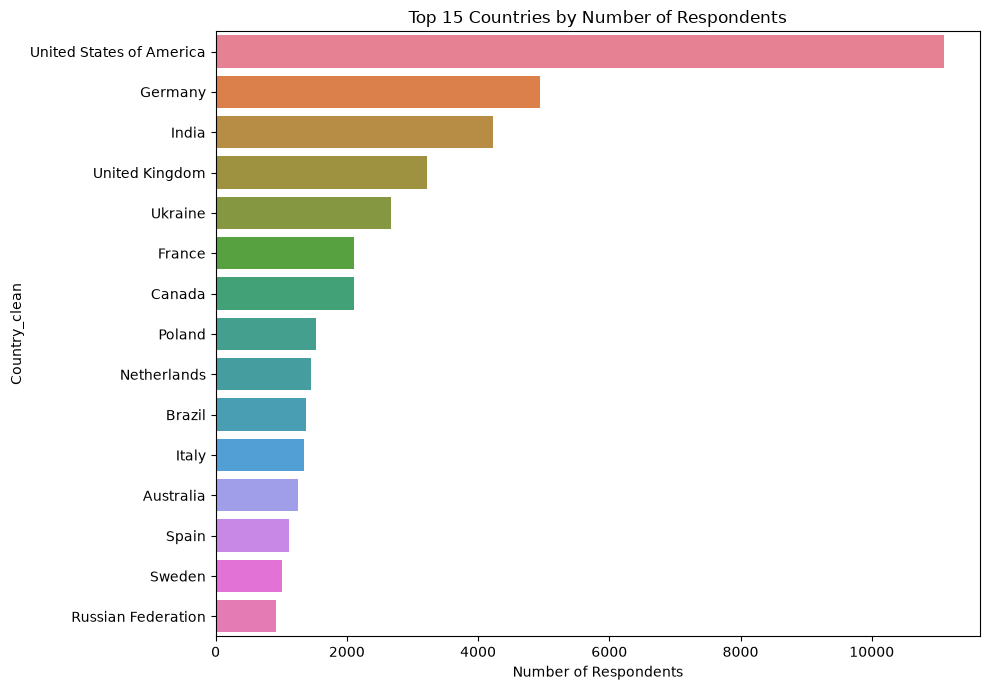

In [59]:
top_countries = df[df['Country_clean'] != 'Not specified']['Country_clean'].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index)
plt.title('Top 15 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.tight_layout()
plt.show()

**Does pay reporting differ by country?** About 64% of respondents didn't report pay.
I check if that's spread evenly across countries.


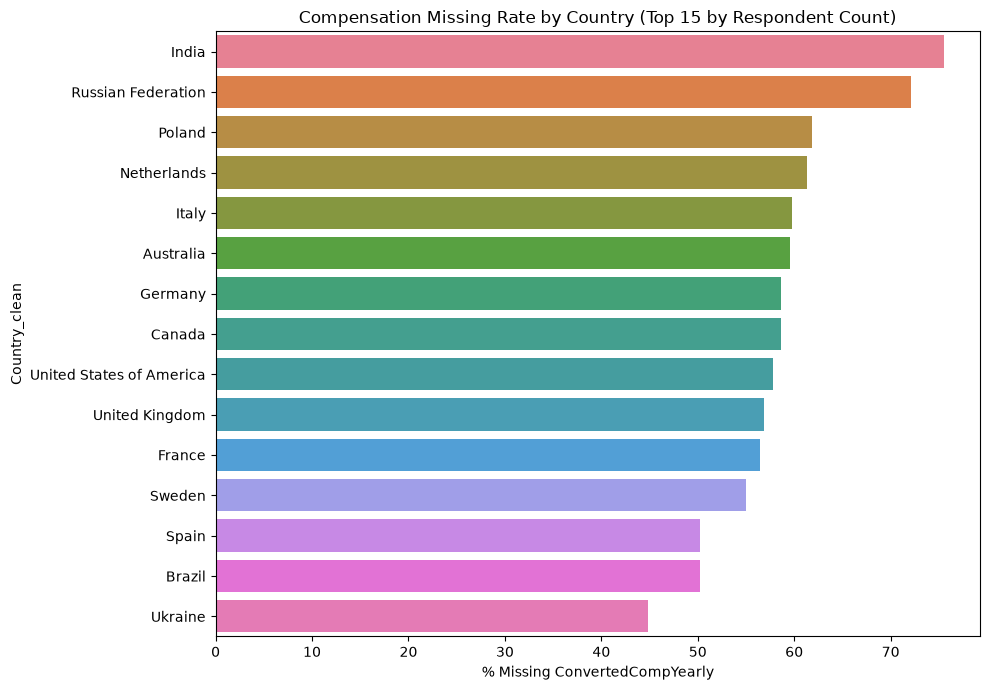

In [60]:
comp_missing_by_country = (
    df[df['Country_clean'].isin(top_countries.index)]
    .groupby('Country_clean')['has_compensation_data']
    .apply(lambda s: (~s).mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=comp_missing_by_country.values, y=comp_missing_by_country.index, hue=comp_missing_by_country.index)
plt.title('Compensation Missing Rate by Country (Top 15 by Respondent Count)')
plt.xlabel('% Missing ConvertedCompYearly')
plt.tight_layout()
plt.show()

### 3. Pay Distribution & Outliers
Research Question 2.


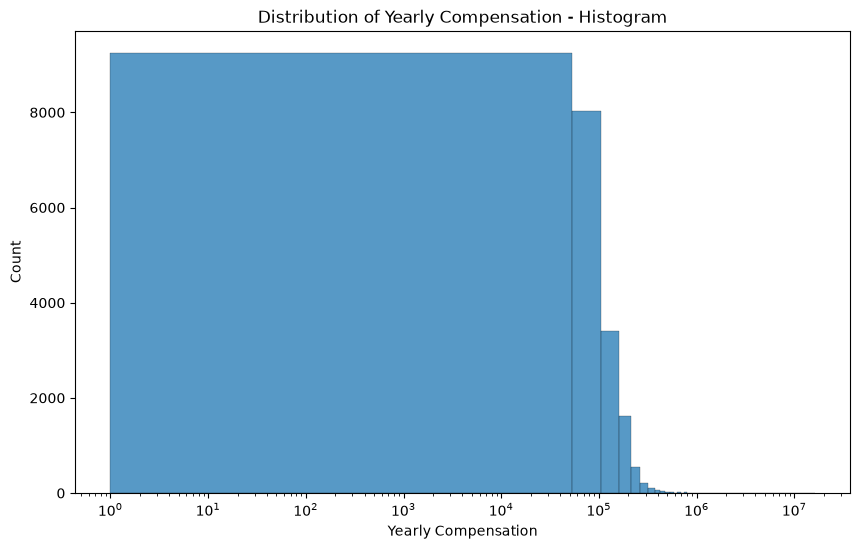

n = 23435 respondents with reported compensation


In [61]:
comp = df_comp['ConvertedCompYearly'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(comp)
plt.xscale('log')
plt.title('Distribution of Yearly Compensation - Histogram')
plt.xlabel('Yearly Compensation')
plt.show()

print(f"n = {len(comp)} respondents with reported compensation")

**Method 1: 3-sigma on the raw value.**


In [62]:
mean = comp.mean()
median = comp.median()
std = comp.std()

print(f'mean: {mean.round()}')
print(f'median: {median.round()}')
print(f'std: {std.round()}')

threshold = mean + 3 * std
outlier = df_comp[df_comp['ConvertedCompYearly'] > threshold]

print(f'threshold: {threshold.round()}')
print(f'\nNumber of outliers: {len(outlier)}')
display(outlier[['ConvertedCompYearly']].sort_values('ConvertedCompYearly', ascending=False).head())

mean: 86155.0
median: 65000.0
std: 186757.0
threshold: 646426.0

Number of outliers: 89


,ConvertedCompYearly
15837,16256603.0
12723,13818022.0
28379,9000000.0
17593,6340564.0
17672,4936778.0


**Method 2: IQR on the raw value.**


Number of Outliers: 978
lower_bound: -80177  |  upper_bound: 220861


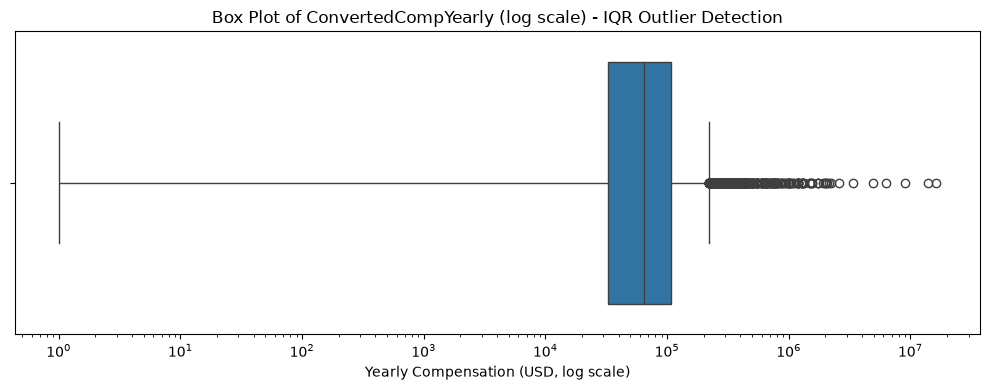

In [63]:
q1 = comp.quantile(0.25)
q3 = comp.quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df_comp[(df_comp['ConvertedCompYearly'] < lower_bound) | (df_comp['ConvertedCompYearly'] > upper_bound)]
outliers_count = len(outliers)

print(f'Number of Outliers: {outliers_count}')
print(f'lower_bound: {lower_bound:.0f}  |  upper_bound: {upper_bound:.0f}')

plt.figure(figsize=(10, 4))
sns.boxplot(x=comp)
plt.xscale('log')
plt.title('Box Plot of ConvertedCompYearly (log scale) - IQR Outlier Detection')
plt.xlabel('Yearly Compensation (USD, log scale)')
plt.tight_layout()
plt.show()

The `lower_bound` above is negative. `ConvertedCompYearly` is heavily skewed
(skewness about 53, from Phase 1), so the raw IQR rule can't flag any low-end outliers.
This is why I need Method 3.


**Method 3: IQR on the log value**, using `ConvertedCompYearly_log` from Phase 1.


Number of Outliers: 1723
lower_bound (comp scale): 5454  |  upper_bound (comp scale): 647443


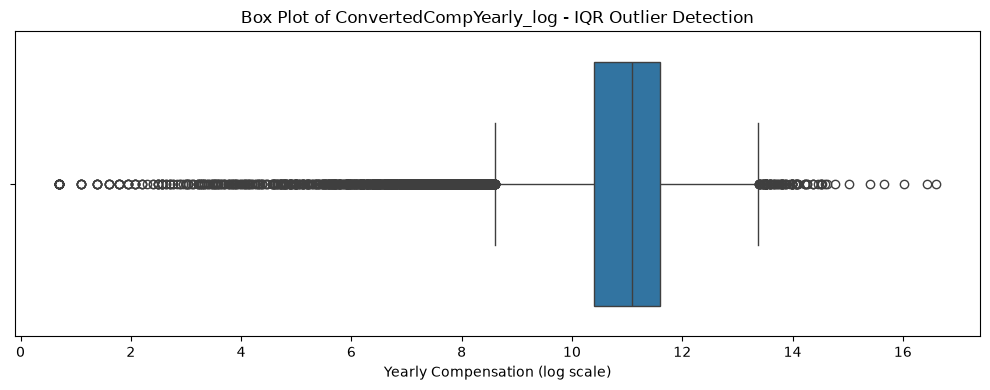

In [64]:
comp_log = df_comp['ConvertedCompYearly_log'].dropna()

q1_log = comp_log.quantile(0.25)
q3_log = comp_log.quantile(0.75)

iqr_log = q3_log - q1_log

lower_bound_log = q1_log - 1.5 * iqr_log
upper_bound_log = q3_log + 1.5 * iqr_log

is_outliers = (comp_log < lower_bound_log) | (comp_log > upper_bound_log)

print(f'Number of Outliers: {is_outliers.sum()}')
print(f'lower_bound (comp scale): {np.expm1(lower_bound_log):.0f}  |  '
      f'upper_bound (comp scale): {np.expm1(upper_bound_log):.0f}')

plt.figure(figsize=(10, 4))
sns.boxplot(x=comp_log)
plt.title('Box Plot of ConvertedCompYearly_log - IQR Outlier Detection')
plt.xlabel('Yearly Compensation (log scale)')
plt.tight_layout()
plt.show()

I only flag outliers, I never drop them. `is_comp_outlier` marks the flagged rows
below, and every row stays in the data.


In [65]:
df['is_comp_outlier'] = False
df.loc[comp_log.index, 'is_comp_outlier'] = is_outliers.values
df_comp['is_comp_outlier'] = df['is_comp_outlier'].reindex(df_comp.index)

print(f"is_comp_outlier flagged for {df['is_comp_outlier'].sum()} of {df['has_compensation_data'].sum()} "
      f"respondents with compensation data ({df['is_comp_outlier'].sum() / df['has_compensation_data'].sum() * 100:.2f}%)")

median_with = df_comp['ConvertedCompYearly'].median()
median_without = df_comp.loc[~df_comp['is_comp_outlier'], 'ConvertedCompYearly'].median()
print(f"Median compensation - with outliers:    ${median_with:,.0f}")
print(f"Median compensation - without outliers: ${median_without:,.0f}")

is_comp_outlier flagged for 1723 of 23435 respondents with compensation data (7.35%)
Median compensation - with outliers:    $65,000
Median compensation - without outliers: $70,000


In [66]:
comparison = pd.DataFrame({
    'Method': ['3-sigma (raw)', 'IQR (raw)', 'IQR (log) - used for is_comp_outlier'],
    'Lower bound (comp scale)': [threshold * 0 + (mean - 3 * std), lower_bound, np.expm1(lower_bound_log)],
    'Upper bound (comp scale)': [threshold, upper_bound, np.expm1(upper_bound_log)],
    'Outliers flagged': [len(outlier), outliers_count, int(is_outliers.sum())],
})
comparison

,Method,Lower bound (comp scale),Upper bound (comp scale),Outliers flagged
0,3-sigma (raw),-474115.631996,646426.206522,89
1,IQR (raw),-80177.250000,220860.750000,978
2,IQR (log) - used for is_comp_outlier,5454.458056,647443.125355,1723


### 4. Salary Drivers
Research Question 3.


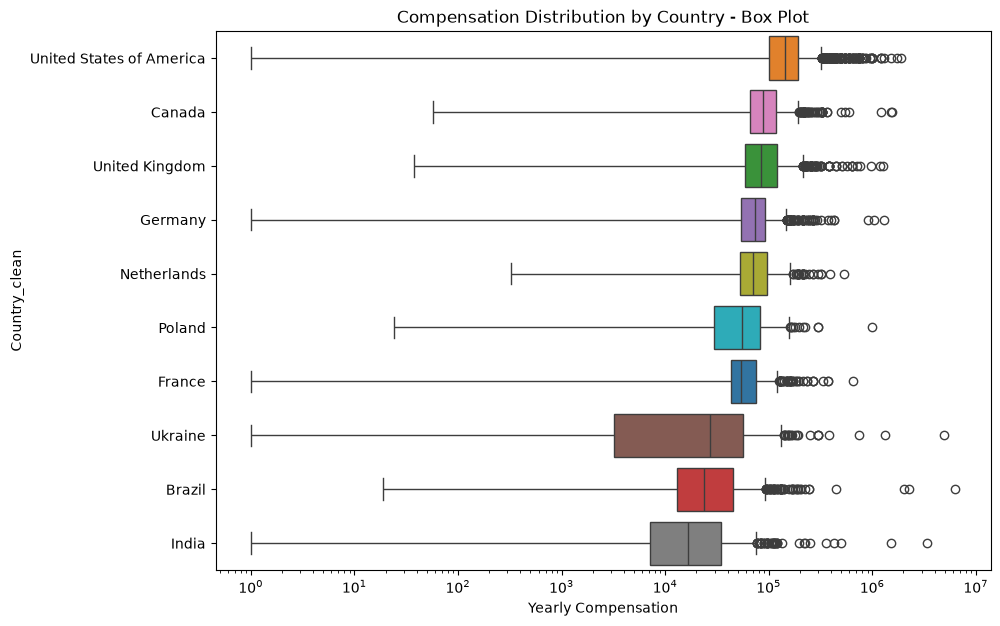

In [67]:
top_countries = df_comp[df_comp['Country_clean'] != 'Not specified']['Country_clean'].value_counts().head(10).index.tolist()

filtered_df = df_comp[df_comp['Country_clean'].isin(top_countries)]

country_order = filtered_df.groupby('Country_clean')['ConvertedCompYearly'].median().sort_values(ascending=False).index.to_list()

plt.figure(figsize=(10, 7))
sns.boxplot(filtered_df, x='ConvertedCompYearly', y='Country_clean', order=country_order, hue='Country_clean')
plt.xscale('log')
plt.xlabel('Yearly Compensation')
plt.title('Compensation Distribution by Country - Box Plot')
plt.show()

I group pay by Phase 1's `ExperienceLevel` tiers, not raw years of experience.


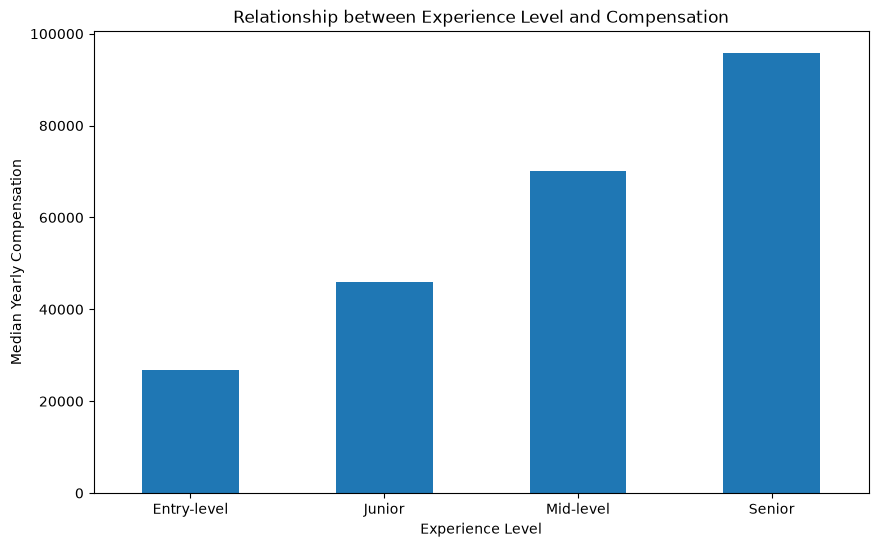

In [68]:
exp_order = ['Entry-level', 'Junior', 'Mid-level', 'Senior']

comp_at_explevel = df_comp.groupby('ExperienceLevel', observed=True)['ConvertedCompYearly'].median().reindex(exp_order)

plt.figure(figsize=(10, 6))
comp_at_explevel.plot(kind='bar')
plt.title('Relationship between Experience Level and Compensation')
plt.xlabel('Experience Level')
plt.ylabel('Median Yearly Compensation')
plt.xticks(rotation=360)
plt.show()

I group pay by `EdLevel_clean` and the one-hot `Employment` columns from Phase 1.


EdLevel_clean,Bachelor's degree,Master's degree,"Some college, no degree",Professional/Doctoral degree,Secondary school,Associate degree,Other,Primary school
"Employed, full-time",45.38,29.54,11.15,5.02,4.29,3.23,0.87,0.51
"Employed, part-time",38.02,22.50,16.14,4.19,13.70,3.00,1.12,1.33
"Independent contractor, freelancer, or self-employed",38.01,29.65,16.23,4.33,6.43,2.96,1.06,1.32
"Not employed, but looking for work",43.21,23.46,15.43,3.09,7.41,2.47,0.62,4.32
"Student, full-time",37.09,15.00,21.63,2.44,18.37,3.26,0.81,1.40
"Student, part-time",41.47,20.27,20.13,1.73,10.67,4.40,0.80,0.53


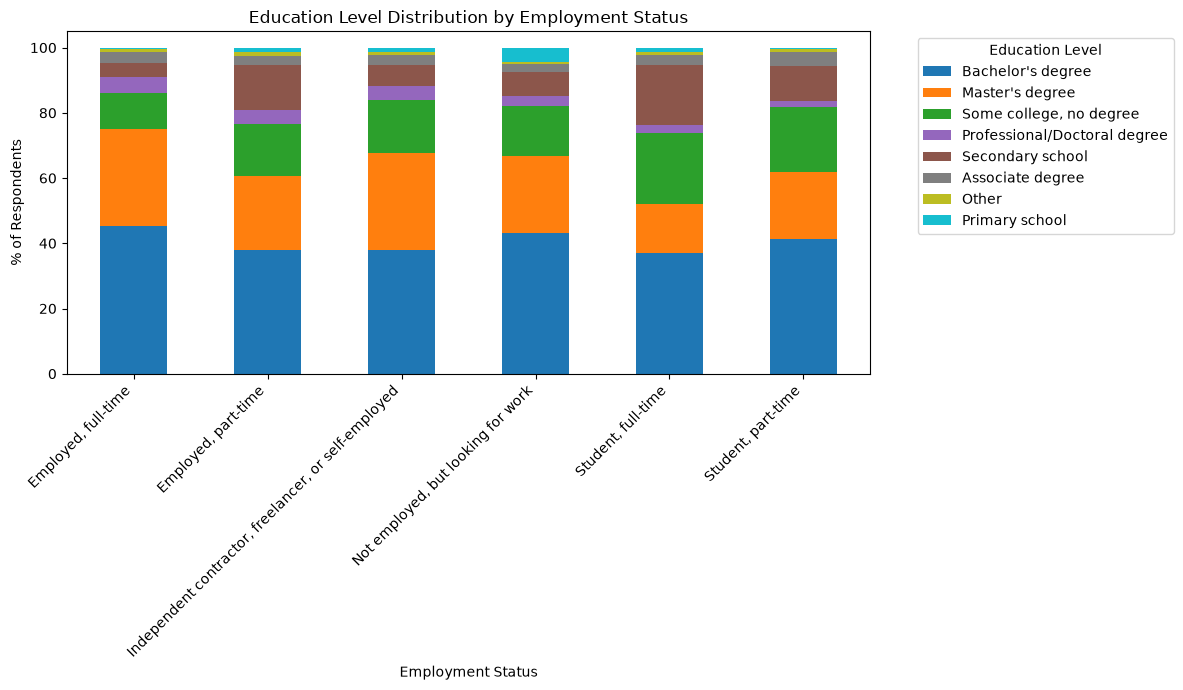

In [69]:
employment_dummy_cols = [
    'Employed, full-time', 'Employed, part-time', 'Independent contractor, freelancer, or self-employed',
    'Not employed, and not looking for work', 'Not employed, but looking for work', 'Retired',
    'Student, full-time', 'Student, part-time', 'I prefer not to say',
]

rows = []
for emp_col in employment_dummy_cols:
    subset = df_comp[df_comp[emp_col] == 1]
    if len(subset) >= 30:
        ct_row = subset['EdLevel_clean'].value_counts(normalize=True) * 100
        ct_row.name = emp_col
        rows.append(ct_row)

ct_empEd = pd.DataFrame(rows).fillna(0)
display(ct_empEd.round(2))

ct_empEd.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10')
plt.title('Education Level Distribution by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel(r'% of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Remote work vs. pay**, shown as a heatmap of median pay by remote-work type.


In [70]:
remote_salary = df_comp.groupby('RemoteWork')['ConvertedCompYearly'].agg(['median', 'count']).sort_values('median', ascending=False)
remote_salary

,median,count
RemoteWork,,
Remote,75000.0,9591
"Hybrid (some remote, some in-person)",66592.0,9907
In-person,44586.0,3937


### 5. Correlation & Multicollinearity
Research Questions 3 and 5.


In [71]:
age_map = {
    '25-34 years old': 30,
    '35-44 years old': 40,
    '18-24 years old': 21,
    '45-54 years old': 50,
    'Under 18 years old': 16,
    '55-64 years old': 60,
    '65 years or older': 67,
    'Prefer not to say': None,
}

df['Age_num'] = df['Age'].replace(age_map).astype(float)

**Multicollinearity check** on the numeric columns I need
(`ConvertedCompYearly_log`, `WorkExp`, `YearsCodePro_num`, `Age_num`, `JobSat`).


Age_num                    1.000000
WorkExp                    0.848214
YearsCodePro_num           0.831817
ConvertedCompYearly_log    0.311606
JobSat                     0.069547
Name: Age_num, dtype: float64


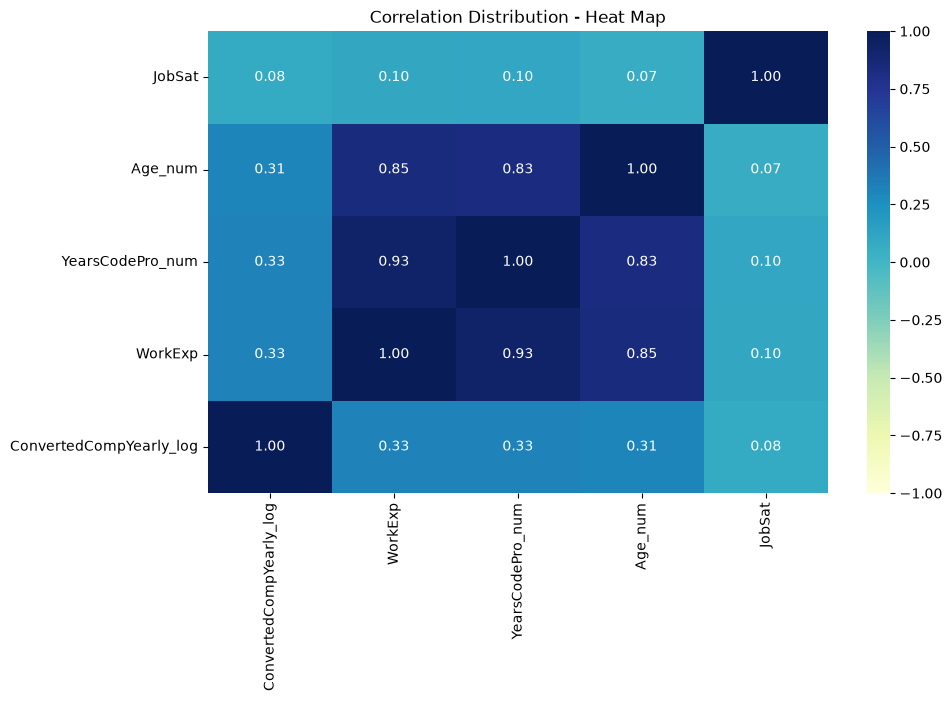

In [72]:
numeric_cols = ['ConvertedCompYearly_log', 'WorkExp', 'YearsCodePro_num', 'Age_num', 'JobSat']
corr = df[numeric_cols].corr()

print(corr['Age_num'].sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='YlGnBu', annot=True, fmt='.2f', vmin=-1, vmax=1)
plt.gca().invert_yaxis()
plt.title('Correlation Distribution - Heat Map')
plt.show()

In [73]:
age_workexp_corr = df['Age_num'].corr(df['WorkExp'])
print(f"Age vs. WorkExp correlation: {age_workexp_corr:.2f}")
if age_workexp_corr >= 0.7:
    print("-> Strong multicollinearity confirmed: consider using only one of these two in Phase 3 modeling.")

Age vs. WorkExp correlation: 0.85
-> Strong multicollinearity confirmed: consider using only one of these two in Phase 3 modeling.


I correlate `YearsCodePro_num` with `JobSat`.


In [74]:
pearson_r = df['YearsCodePro_num'].corr(df['JobSat'], method='pearson')
spearman_r = df['YearsCodePro_num'].corr(df['JobSat'], method='spearman')

print(f'Pearson correlation coefficient: {pearson_r:.3f}')
print(f'Spearman correlation coefficient: {spearman_r:.3f}')

Pearson correlation coefficient: 0.104
Spearman correlation coefficient: 0.119


**Correlation with and without outliers.** `refined_df` uses the `is_comp_outlier`
flag from Section 3.


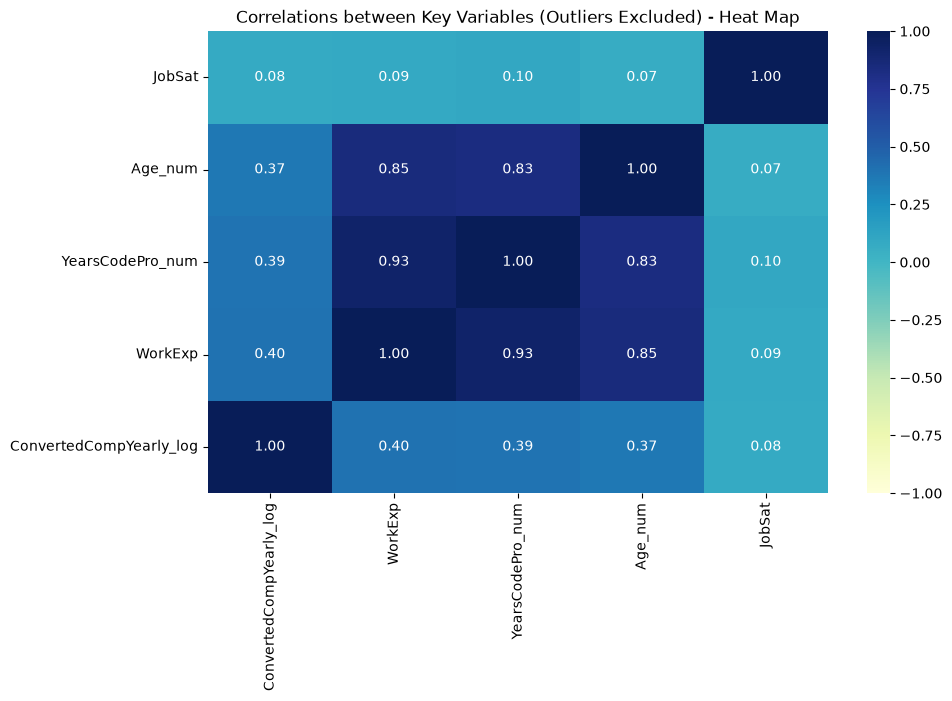

In [75]:
refined_df = df[~df['is_comp_outlier']]

key_cols = ['ConvertedCompYearly_log', 'WorkExp', 'YearsCodePro_num', 'Age_num', 'JobSat']
key_df = refined_df[key_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(key_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=-1, vmax=1)
plt.title('Correlations between Key Variables (Outliers Excluded) - Heat Map')
plt.gca().invert_yaxis()
plt.show()

I use `JobSat` in both panels below.


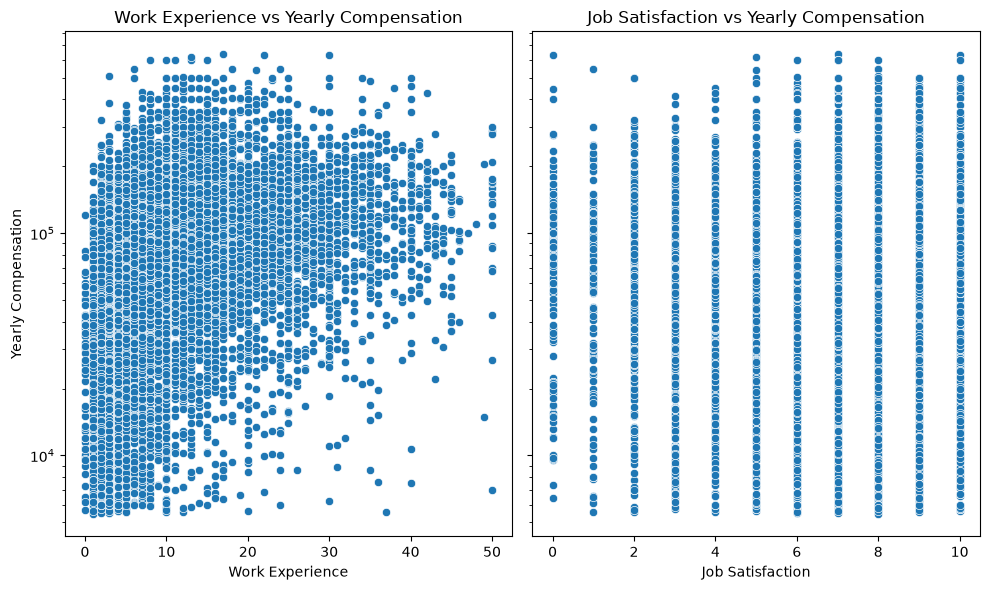

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

sns.scatterplot(refined_df, x='WorkExp', y='ConvertedCompYearly', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Work Experience vs Yearly Compensation')
axes[0].set_xlabel('Work Experience')
axes[0].set_ylabel('Yearly Compensation')

sns.scatterplot(refined_df, x='JobSat', y='ConvertedCompYearly', ax=axes[1])
axes[1].set_title('Job Satisfaction vs Yearly Compensation')
axes[1].set_xlabel('Job Satisfaction')
plt.tight_layout()
plt.show()

### 6. Market Trends
Research Question 4.


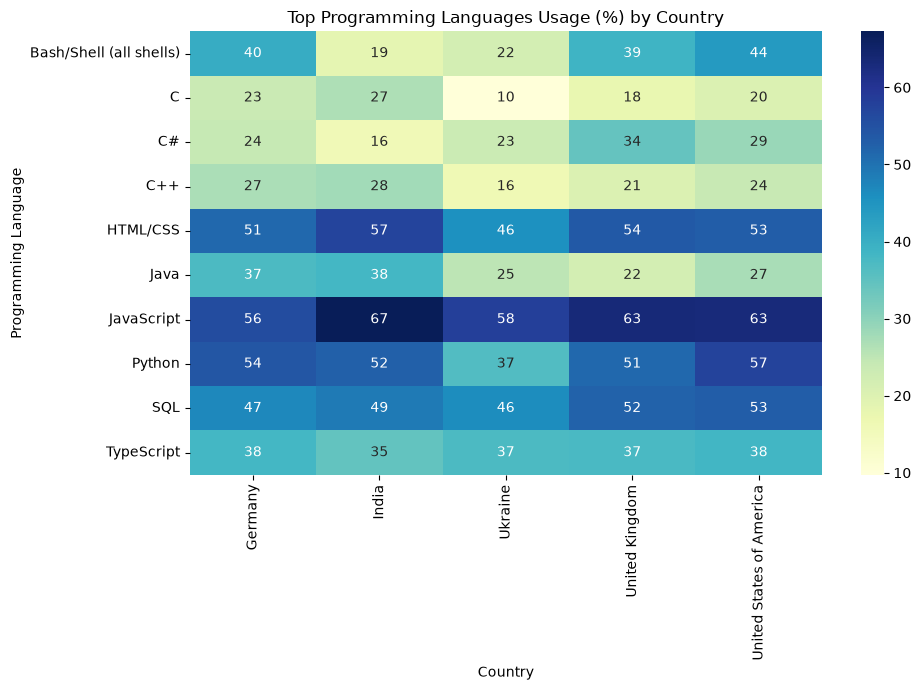

In [77]:
# Filter the data by top 5 countries with most respondents
top_countries = df[df['Country_clean'] != 'Not specified']['Country_clean'].value_counts().head().index.to_list()
df_filtered = df[df['Country_clean'].isin(top_countries)].copy()

# Explode the data to separate languages (dropna first, so the % denominator is explicit)
df_filtered = df_filtered[df_filtered['LanguageHaveWorkedWith'].notna()].copy()
df_filtered['LanguageHaveWorkedWith'] = df_filtered['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_filtered.explode('LanguageHaveWorkedWith')

lang_by_country = df_exploded.groupby(['Country_clean', 'LanguageHaveWorkedWith']).size().reset_index(name='Count')
total_count = df_filtered['Country_clean'].value_counts()
lang_by_country['pct'] = lang_by_country.apply(lambda r: (r['Count'] / total_count[r['Country_clean']]) * 100, axis=1)

# Top 10 most popular languages
top10 = lang_by_country.groupby('LanguageHaveWorkedWith').Count.sum().sort_values(ascending=False).head(10).index
pivot = lang_by_country[lang_by_country['LanguageHaveWorkedWith'].isin(top10)].pivot(
    index='LanguageHaveWorkedWith', columns='Country_clean', values='pct'
)

plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Top Programming Languages Usage (%) by Country')
plt.xlabel('Country')
plt.ylabel('Programming Language')
plt.tight_layout()
plt.show()

**Have vs. Want gap.** I drop missing values before splitting each field, so the
denominator is clear.


,Have Worked With (%),Want To Work With (%),Gap (Want - Have)
JavaScript,62.75,42.64,-20.11
HTML/CSS,53.25,37.17,-16.09
Python,51.42,44.93,-6.49
SQL,51.35,40.18,-11.18
TypeScript,38.75,36.30,-2.45
Bash/Shell (all shells),34.17,24.65,-9.51
Java,30.53,19.13,-11.39
C#,27.31,23.18,-4.14
C++,23.14,19.50,-3.64
C,20.39,14.84,-5.55


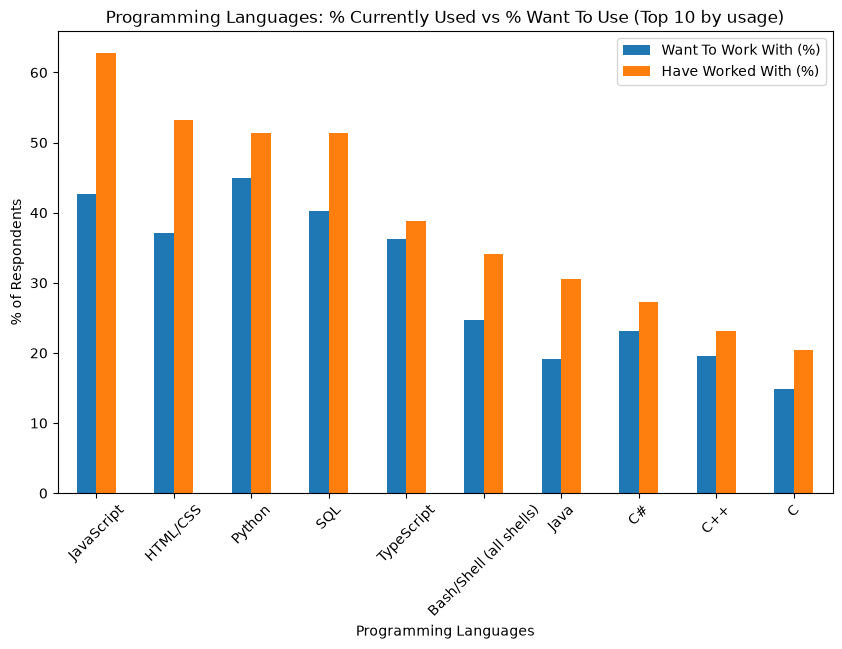

In [78]:
have_series = df['LanguageHaveWorkedWith'].dropna()
want_series = df['LanguageWantToWorkWith'].dropna()

explode_have = have_series.str.split(';').explode().value_counts()
explode_want = want_series.str.split(';').explode().value_counts()

have_pct = explode_have / have_series.count() * 100
want_pct = explode_want / want_series.count() * 100

compare = pd.DataFrame({
    'Have Worked With (%)': have_pct,
    'Want To Work With (%)': want_pct,
}).fillna(0)

compare['Gap (Want - Have)'] = compare['Want To Work With (%)'] - compare['Have Worked With (%)']

top10 = compare.sort_values('Have Worked With (%)', ascending=False).head(10)
display(top10.round(2))

top10[['Want To Work With (%)', 'Have Worked With (%)']].plot(kind='bar', figsize=(10, 6))
plt.title('Programming Languages: % Currently Used vs % Want To Use (Top 10 by usage)')
plt.xlabel('Programming Languages')
plt.ylabel(r'% of Respondents')
plt.xticks(rotation=45)
plt.legend()
plt.show()

,Have Worked With (%),Want To Work With (%),Gap (Want - Have)
Rust,12.65,30.91,18.26
Go,13.56,24.82,11.26
Zig,1.12,6.62,5.50
Kotlin,9.48,13.24,3.75
Elixir,2.08,5.19,3.11
Swift,4.74,6.95,2.22
Haskell,2.00,3.98,1.99
F#,0.86,2.28,1.42
OCaml,0.77,1.94,1.17
Erlang,0.87,2.04,1.17


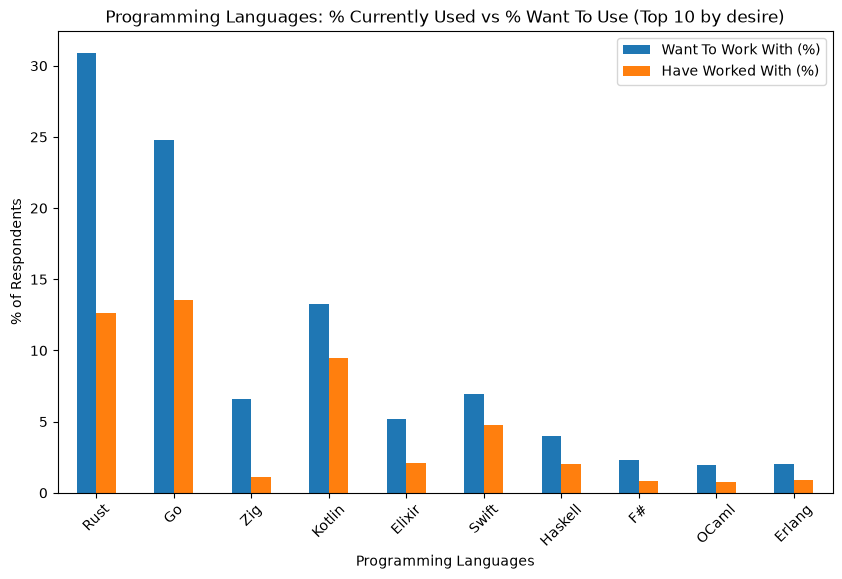

In [79]:
hot = compare.sort_values('Gap (Want - Have)', ascending=False).head(10)
display(hot.round(2))

hot[['Want To Work With (%)', 'Have Worked With (%)']].plot(kind='bar', figsize=(10, 6))
plt.title('Programming Languages: % Currently Used vs % Want To Use (Top 10 by desire)')
plt.xlabel('Programming Languages')
plt.ylabel(r'% of Respondents')
plt.xticks(rotation=45)
plt.legend()
plt.show()

**Remote work by country**, shown as a heatmap and bar chart.


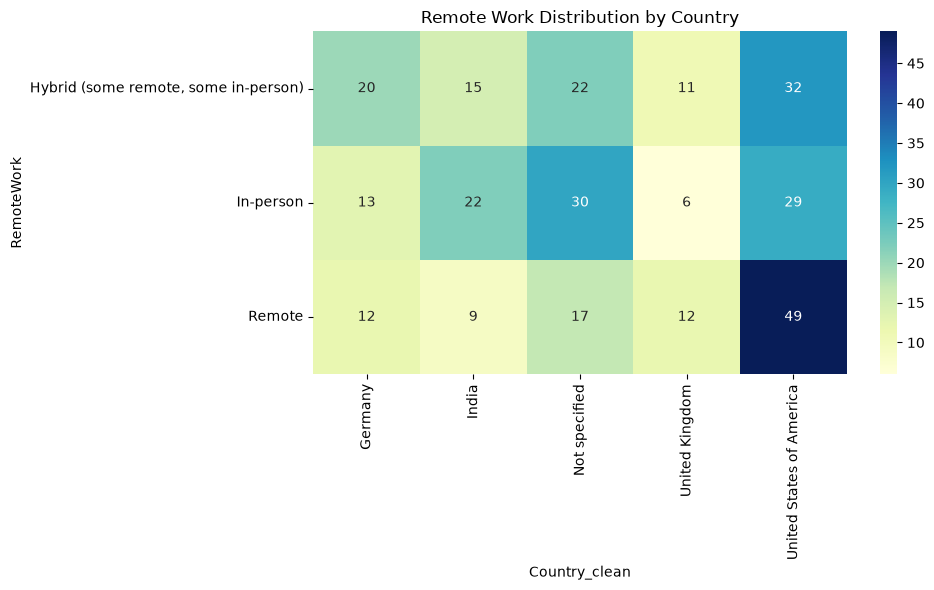

In [80]:
top_countries = df['Country_clean'].value_counts().head(5).index.to_list()
df_filtered = df[df['Country_clean'].isin(top_countries)]

ct = pd.crosstab(df_filtered['RemoteWork'], df_filtered['Country_clean'], normalize='index').round(2) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Remote Work Distribution by Country')
plt.tight_layout()
plt.show()

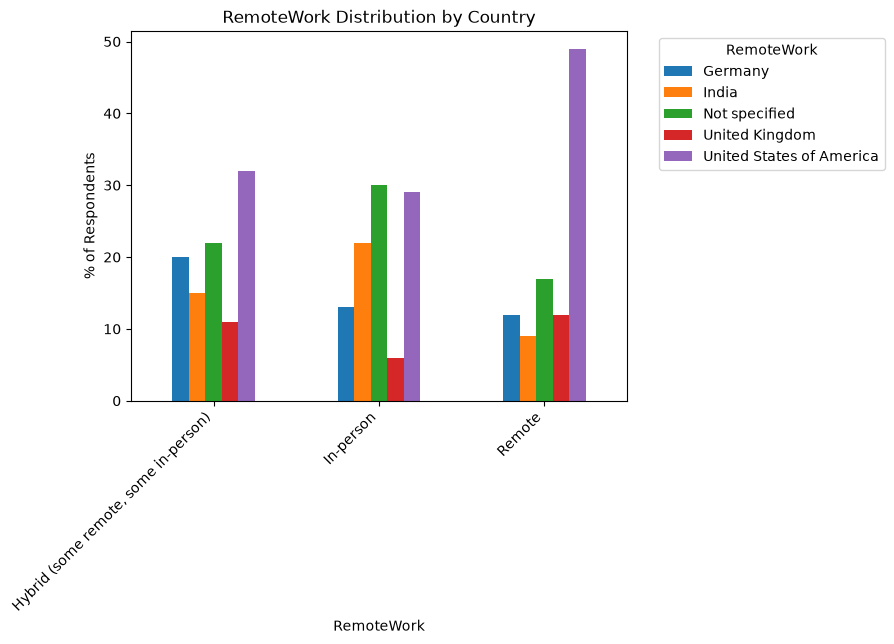

In [81]:
ct.plot(kind='bar')
plt.title('RemoteWork Distribution by Country')
plt.ylabel(r'% of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='RemoteWork', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Median pay by language.** Same explode-and-group method as above, filtered to at
least 30 respondents per language (`MIN_N_LANG = 30`), so rare languages don't skew the
result.


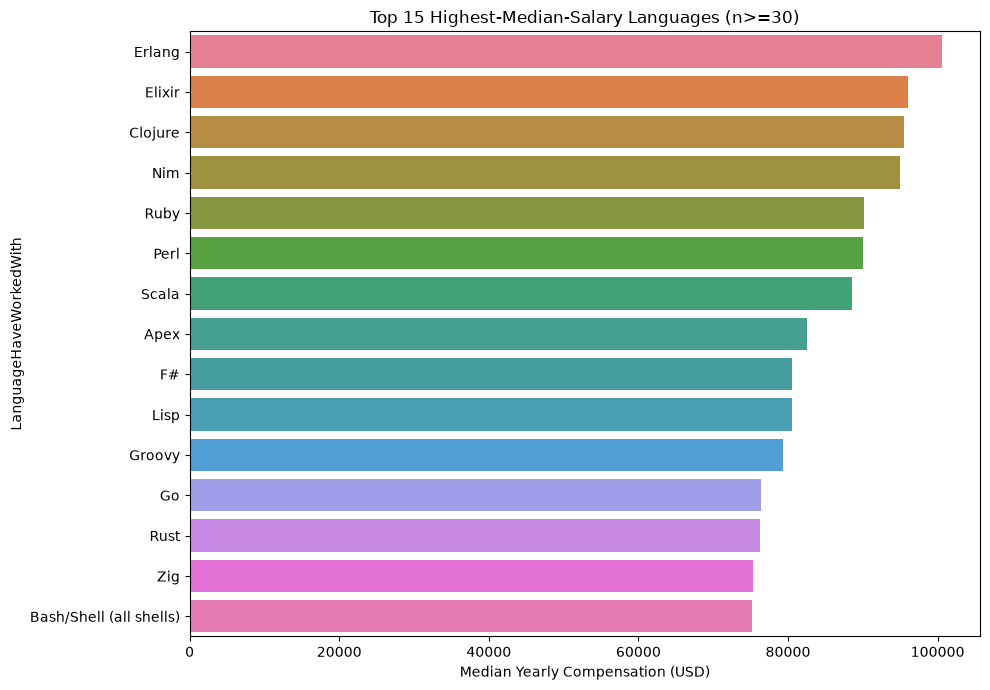

,median,n
LanguageHaveWorkedWith,,
Erlang,100636.0,229
Elixir,96000.0,598
Clojure,95541.0,350
Nim,94923.5,34
Ruby,90221.0,1372
Perl,90000.0,563
Scala,88619.0,693
Apex,82500.0,202
F#,80555.0,216


In [82]:
MIN_N_LANG = 30

lang_salary = df_comp[df_comp['LanguageHaveWorkedWith'].notna()].copy()
lang_salary['LanguageHaveWorkedWith'] = lang_salary['LanguageHaveWorkedWith'].str.split(';')
lang_salary = lang_salary.explode('LanguageHaveWorkedWith')

lang_salary_summary = (
    lang_salary.groupby('LanguageHaveWorkedWith')['ConvertedCompYearly']
    .agg(median='median', n='count')
    .query('n >= @MIN_N_LANG')
    .sort_values('median', ascending=False)
)

top_paid_langs = lang_salary_summary.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_paid_langs['median'], y=top_paid_langs.index, hue=top_paid_langs.index)
plt.title(f'Top 15 Highest-Median-Salary Languages (n>={MIN_N_LANG})')
plt.xlabel('Median Yearly Compensation (USD)')
plt.tight_layout()
plt.show()

top_paid_langs

### 7. Job Satisfaction
Research Question 5.


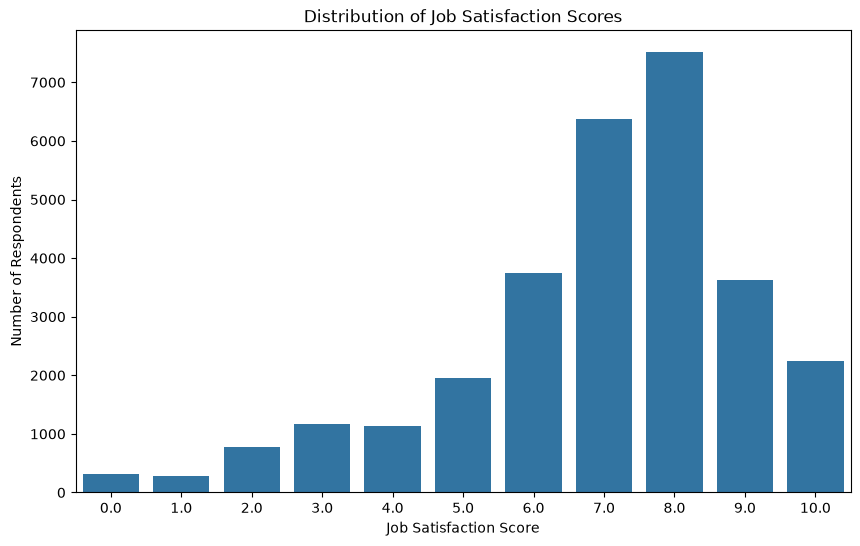

In [83]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['JobSat'].dropna())
plt.title('Distribution of Job Satisfaction Scores')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Number of Respondents')
plt.show()

`JobSat` distribution, shown as a KDE plot with the median marked.


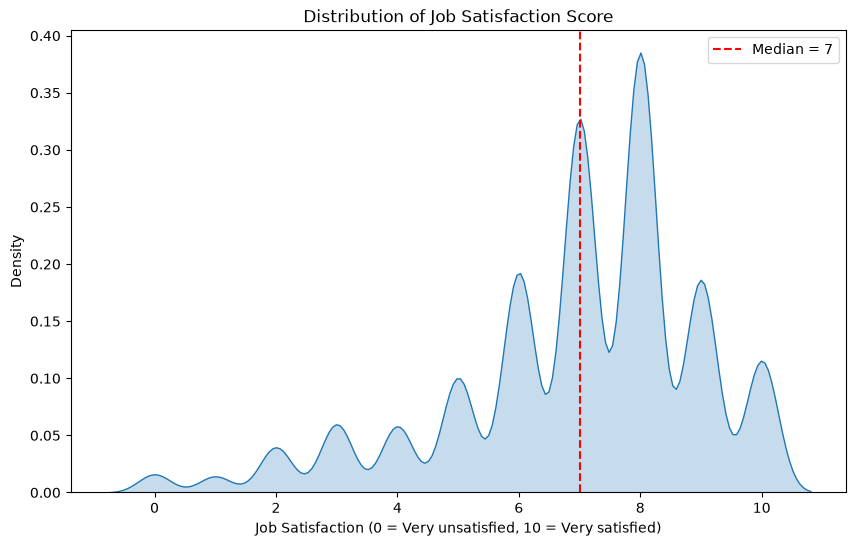

In [84]:
label = f"Median = {df['JobSat'].median():.0f}"

plt.figure(figsize=(10, 6))
sns.kdeplot(df['JobSat'], fill=True)
plt.axvline(df['JobSat'].median(), linestyle='--', color='red', label=label)
plt.legend()
plt.title('Distribution of Job Satisfaction Score')
plt.xlabel('Job Satisfaction (0 = Very unsatisfied, 10 = Very satisfied)')
plt.show()

**JobSat by experience level**, grouped by Phase 1's `ExperienceLevel` tiers.


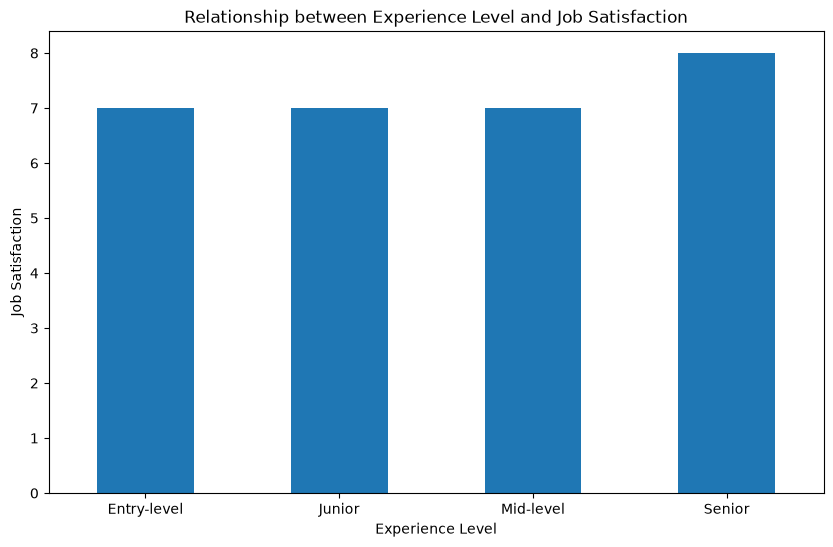

In [85]:
jobsat_at_explevel = df.groupby('ExperienceLevel', observed=True)['JobSat'].median().reindex(exp_order)

plt.figure(figsize=(10, 6))
jobsat_at_explevel.plot(kind='bar')
plt.title('Relationship between Experience Level and Job Satisfaction')
plt.xlabel('Experience Level')
plt.ylabel('Job Satisfaction')
plt.xticks(rotation=360)
plt.show()

**JobSat vs. pay**, correlated against `ConvertedCompYearly_log`.


In [86]:
jobsat_comp = df.dropna(subset=['JobSat', 'ConvertedCompYearly_log'])

pearson_r = jobsat_comp['JobSat'].corr(jobsat_comp['ConvertedCompYearly_log'], method='pearson')
spearman_r = jobsat_comp['JobSat'].corr(jobsat_comp['ConvertedCompYearly_log'], method='spearman')

print(f'n = {len(jobsat_comp)} respondents with both JobSat and compensation reported')
print(f'Pearson correlation coefficient: {pearson_r:.3f}')
print(f'Spearman correlation coefficient: {spearman_r:.3f}')

n = 16075 respondents with both JobSat and compensation reported
Pearson correlation coefficient: 0.080
Spearman correlation coefficient: 0.103


### 8. Key Findings & Data Export
Run all cells above first. The numbers below need real data.


In [87]:
print("=== Phase 2 EDA - Summary Snapshot ===\n")
print(f"Respondents with compensation data: {df['has_compensation_data'].sum()} "
      f"({df['has_compensation_data'].mean()*100:.2f}%)")
print(f"Compensation outliers flagged (IQR on log scale): {df['is_comp_outlier'].sum()} "
      f"({df['is_comp_outlier'].sum()/df['has_compensation_data'].sum()*100:.2f}% of the compensation subset)")
print(f"RemoteWork values imputed in Phase 1: {df['RemoteWork_imputed'].sum()} "
      f"({df['RemoteWork_imputed'].mean()*100:.2f}%)")
print(f"JobSat answered by: {df['JobSat'].notna().sum()} respondents ({df['JobSat'].notna().mean()*100:.2f}%)")
print(f"Age vs. WorkExp correlation: {age_workexp_corr:.2f}")
print(f"JobSat vs. log-compensation correlation (Pearson): {pearson_r:.3f}")

=== Phase 2 EDA - Summary Snapshot ===

Respondents with compensation data: 23435 (35.81%)
Compensation outliers flagged (IQR on log scale): 1723 (7.35% of the compensation subset)
RemoteWork values imputed in Phase 1: 10631 (16.25%)
JobSat answered by: 29126 respondents (44.51%)
Age vs. WorkExp correlation: 0.85
JobSat vs. log-compensation correlation (Pearson): 0.080


**Ideas for Phase 3:**
1. Country and `ExperienceLevel` are likely the strongest predictors of pay.
2. Open item, not solved here: `Age_num` and `WorkExp` are highly correlated (r = 0.85,
   Section 5). Phase 3 must pick one, or combine them.
3. I should test pay outliers with and without exclusion, to see their effect on any model.
4. Language choice might add a pay signal beyond country and experience.


**Export.** I save the EDA-ready dataset, with the flags I made here
(`is_comp_outlier`, `RemoteWork_imputed`, `CodingActivities_imputed`), so Phase 3 can load
one file instead of running this notebook again.


In [88]:
output_path = f'{DATA_DIR}/survey_data_eda_ready.csv'
df.to_csv(output_path, index=False)

print(f"Saved {df.shape[0]} rows x {df.shape[1]} columns to '{output_path}'")
print(f"\nNew columns added in Phase 2: {[c for c in df.columns if c not in df_core.columns]}")

Saved 65437 rows x 40 columns to '../data/survey_data_eda_ready.csv'

New columns added in Phase 2: ['Age', 'RemoteWork_raw', 'CodingActivities_raw', 'DevType', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'WorkExp', 'Industry', 'JobSatPoints_1', 'JobSat', 'RemoteWork_imputed', 'CodingActivities_imputed', 'is_comp_outlier', 'Age_num']


### Executive Summary
- **Data joined:** I joined Phase 1's core file with `JobSat`, `WorkExp`, `Age`, `DevType`,
  `Industry`, and the two language fields from the full file.
- **Imputation audit:** I found which `RemoteWork` (16.25%) and `CodingActivities` (16.77%)
  values were filled in by Phase 1.
- **Missing values:** no new imputation. Every analysis uses `dropna()` and reports `n`.
- **DevType / Industry:** both are single-select in this data (Section 2), so I use them
  as-is.
- **Outliers:** I compared 3 methods - 3-sigma raw (89 flagged), IQR raw (978 flagged), and
  IQR on log (1,723 flagged, 7.35% of the pay subset). I picked IQR-on-log because the raw
  data is skewed. `is_comp_outlier` flags them, but I don't drop any row.
- **Salary drivers, correlations, trends, and satisfaction:** covered in Research Questions
  3-5, using Phase 1's cleaned columns.
- **Open item for Phase 3:** `Age_num` and `WorkExp` are highly correlated (r = 0.85).
  Phase 3 must pick one, or combine them.
- **Output:** `data/survey_data_eda_ready.csv`, ready for Phase 3.
